# 必要なライブラリをインポート
最初に、CLIPModelクラスオブジェクトを作成し、from_pretrainedメソッドを使用してモデル構成と重みで初期化する必要があります。モデルは Hugging Face Hub から自動的にダウンロードされ、次回の使用のためにキャッシュされます。
CLIPProcessorクラスは入力データの前処理用のラッパーです。トークナイザーを使用したテキストのエンコードと画像の準備の両方が含まれます。

In [1]:
%pip install --upgrade pip
%pip install -q --extra-index-url https://download.pytorch.org/whl/cpu "gradio>=4.19" "matplotlib>=3.4" "openvino>=2023.1.0" "transformers[torch]>=4.30" "datasets" "nncf>=2.6.0" "torch>=2.1" Pillow

import requests

r = requests.get(
    url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
)
open("notebook_utils.py", "w").write(r.text)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


25771

In [2]:
from transformers import CLIPProcessor, CLIPModel

# load pre-trained model
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")
# load preprocessor for model input
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
from typing import List
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def visualize_result(image: Image, labels: List[str], probs: np.ndarray, top: int = 5):
    """
    Utility function for visualization classification results
    params:
      image: input image
      labels: list of classification labels
      probs: model predicted softmaxed probabilities for each label
      top: number of the highest probability results for visualization
    returns:
      None
    """
    plt.figure(figsize=(64, 64))
    top_labels = np.argsort(-probs)[: min(top, probs.shape[0])]
    top_probs = probs[top_labels]
    plt.subplot(8, 8, 1)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(8, 8, 2)
    y = np.arange(top_probs.shape[-1])
    plt.grid()
    plt.barh(y, top_probs)
    plt.gca().invert_yaxis()
    plt.gca().set_axisbelow(True)
    plt.yticks(y, [labels[index] for index in top_labels])
    plt.xlabel("probability")

# PyTorchモデルを使用した推論の実行
推論を実行するには、ラベルを定義し、RGB 形式で画像を読み込みます。
モデルに幅広いテキストコンテキストを与え、ガイダンスを改善するために、テンプレート「これは a の写真です」を使用してラベルの説明を拡張します。
ラベルの説明のリストと画像の両方をプロセッサに渡して、モデル固有の形式の入力データを含む辞書を取得する必要があります。
モデルは、生のロジット形式で画像とテキストの類似性スコアを予測します。これは、softmax関数を使用して[0, 1]範囲に正規化できます。
次に、最終結果に対して、最も高い類似性スコアを持つラベルを選択します。

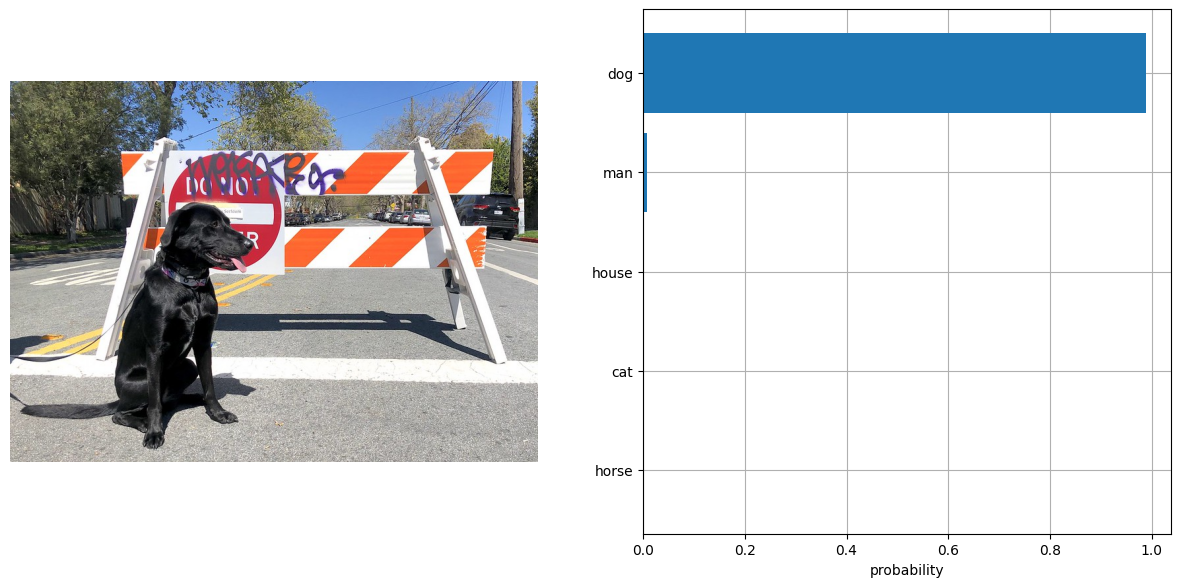

In [4]:
import requests
from pathlib import Path


sample_path = Path("data/coco.jpg")
sample_path.parent.mkdir(parents=True, exist_ok=True)
r = requests.get("https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco.jpg")

with sample_path.open("wb") as f:
    f.write(r.content)

image = Image.open(sample_path)

input_labels = [
    "cat",
    "dog",
    "wolf",
    "tiger",
    "man",
    "horse",
    "frog",
    "tree",
    "house",
    "computer"
]
text_descriptions = [f"This is a photo of a {label}" for label in input_labels]

inputs = processor(text=text_descriptions, images=[image], return_tensors="pt", padding=True)

results = model(**inputs)
logits_per_image = results["logits_per_image"]  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1).detach().numpy()  # we can take the softmax to get the label probabilities
visualize_result(image, input_labels, probs[0])

# PytorchモデルのOpenVINO IR形式への変換

In [5]:
import openvino as ov

fp16_model_path = Path("clip-vit-base-patch16.xml")
model.config.torchscript = True

if not fp16_model_path.exists():
    ov_model = ov.convert_model(model, example_input=dict(inputs))
    ov.save_model(ov_model, fp16_model_path)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


# OpenVINOモデルの実行

In [6]:
from scipy.special import softmax

# create OpenVINO core object instance
core = ov.Core()

# 推論デバイスの選択

In [7]:
%pip install ipywidgets

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [8]:
from notebook_utils import device_widget

device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

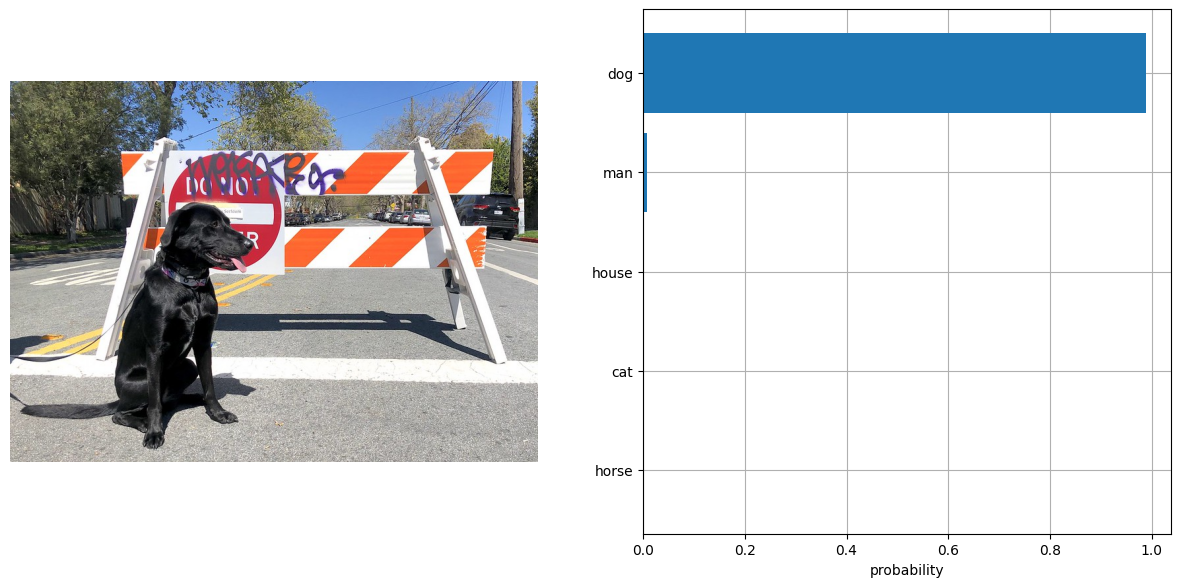

In [9]:
# compile model for loading on device
compiled_model = core.compile_model(fp16_model_path, device.value)
# run inference on preprocessed data and get image-text similarity score
ov_logits_per_image = compiled_model(dict(inputs))[0]
# perform softmax on score
probs = softmax(ov_logits_per_image, axis=1)
# visualize prediction
visualize_result(image, input_labels, probs[0])

# NNCF を使用してモデルを INT8 に量子化する

In [10]:
from notebook_utils import quantization_widget

to_quantize = quantization_widget()

to_quantize

Checkbox(value=True, description='Quantization')

In [11]:
# Fetch skip_kernel_extension module
r = requests.get(
    url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
)
open("skip_kernel_extension.py", "w").write(r.text)

%load_ext skip_kernel_extension

# データセットの準備

In [12]:
%%skip not $to_quantize.value

import requests
from io import BytesIO
import numpy as np
from PIL import Image
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)

max_length = model.config.text_config.max_position_embeddings

def check_text_data(data):
    """
    Check if the given data is text-based.
    """
    if isinstance(data, str):
        return True
    if isinstance(data, list):
        return all(isinstance(x, str) for x in data)
    return False

def get_pil_from_url(url):
    """
    Downloads and converts an image from a URL to a PIL Image object.
    """
    response = requests.get(url, verify=False, timeout=20)
    image = Image.open(BytesIO(response.content))
    return image.convert("RGB")

def collate_fn(example, image_column="image_url", text_column="caption"):
    """
    Preprocesses an example by loading and transforming image and text data.
    Checks if the text data in the example is valid by calling the `check_text_data` function.
    Downloads the image specified by the URL in the image_column by calling the `get_pil_from_url` function.
    If there is any error during the download process, returns None.
    Returns the preprocessed inputs with transformed image and text data.
    """
    assert len(example) == 1
    example = example[0]

    if not check_text_data(example[text_column]):
        raise ValueError("Text data is not valid")

    url = example[image_column]
    try:
        image = get_pil_from_url(url)
        h, w = image.size
        if h == 1 or w == 1:
            return None
    except Exception:
        return None

    inputs = processor(text=example[text_column], images=[image], return_tensors="pt", padding=True)
    if inputs['input_ids'].shape[1] > max_length:
        return None
    return inputs

In [13]:
%%skip not $to_quantize.value

import torch
from datasets import load_dataset
from tqdm.notebook import tqdm

def prepare_calibration_data(dataloader, init_steps):
    """
    This function prepares calibration data from a dataloader for a specified number of initialization steps.
    It iterates over the dataloader, fetching batches and storing the relevant data.
    """
    data = []
    print(f"Fetching {init_steps} samples for the initialization...")
    with tqdm(total=init_steps) as pbar:
        for batch in dataloader:
            if len(data) == init_steps:
                break
            if batch:
                pbar.update(1)
                with torch.no_grad():
                    data.append(
                        {
                            "pixel_values": batch["pixel_values"].to("cpu"),
                            "input_ids": batch["input_ids"].to("cpu"),
                            "attention_mask": batch["attention_mask"].to("cpu")
                        }
                    )
    return data


def prepare_dataset(opt_init_steps=50, max_train_samples=1000):
    """
    Prepares a vision-text dataset for quantization.
    """
    dataset = load_dataset("google-research-datasets/conceptual_captions", trust_remote_code=True)
    train_dataset = dataset["train"].shuffle(seed=42)
    dataloader = torch.utils.data.DataLoader(train_dataset, collate_fn=collate_fn, batch_size=1)
    calibration_data = prepare_calibration_data(dataloader, opt_init_steps)
    return calibration_data

In [14]:
import sys
!{sys.executable} -m pip install ipywidgets tqdm


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


# 量子化の実行
事前トレーニング済みFP16モデルから量子化モデルを作成します。

In [ ]:
import nncf
import openvino as ov
from nncf.quantization.advanced_parameters import (
    AdvancedQuantizationParameters,
    RangeEstimatorParameters
)

# モデル読み込み
core = ov.Core()
ov_model = core.read_model("clip-vit-base-patch16.xml")

# キャリブレーションデータ（精度劣化を意図）
all_data = prepare_dataset()
calibration_data = all_data[:3]
calibration_dataset = nncf.Dataset(calibration_data)

# INT8量子化（精度をあえて落とす設定）
quantized_model = nncf.quantize(
    model=ov_model,
    calibration_dataset=calibration_dataset,
    model_type=nncf.ModelType.TRANSFORMER,
    advanced_parameters=AdvancedQuantizationParameters(
        smooth_quant_alpha=1.0
        )
)

# モデル保存
ov.save_model(quantized_model, "clip-vit-base-patch16_int8_lowacc.xml")
print("✅ INT8モデル（意図的に精度が悪い）を保存しました。")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Output()

RuntimeError: Exception from src/inference/src/cpp/infer_request.cpp:205:
Check 'inputs.size() == 1' failed at src/inference/src/cpp/infer_request.cpp:207:
get_input_tensor() must be called on a function with exactly one parameter.



# 量子化されたモデルを実行

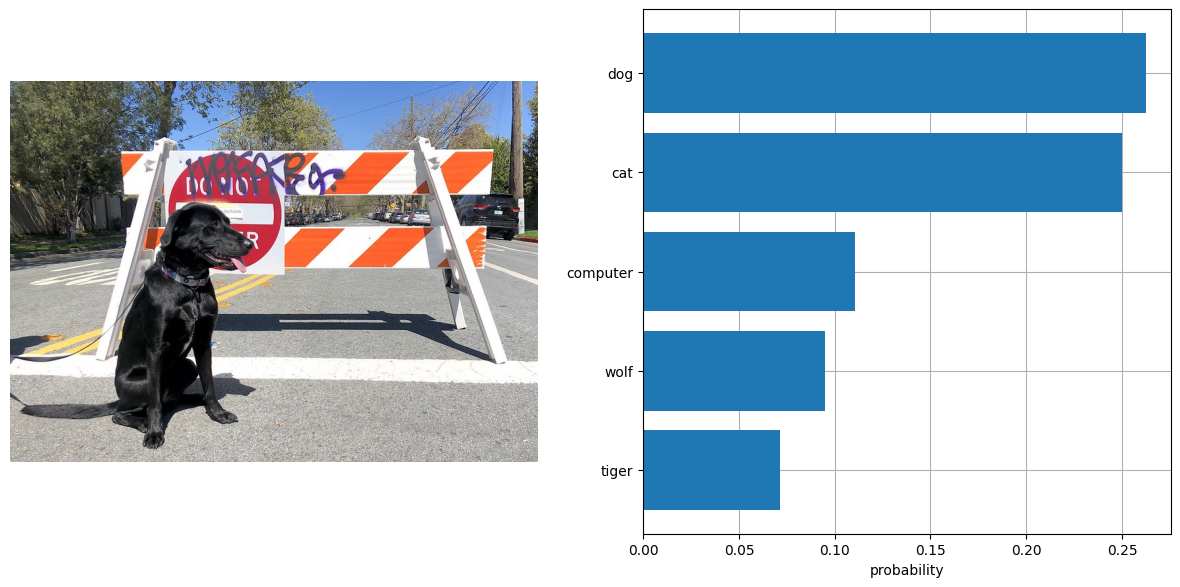

In [33]:
%%skip not $to_quantize.value

# compile model for loading on device
compiled_model = core.compile_model(quantized_model, device.value)
# run inference on preprocessed data and get image-text similarity score
ov_logits_per_image = compiled_model(dict(inputs))[0]
# perform softmax on score
probs = softmax(ov_logits_per_image, axis=1)
# visualize prediction
visualize_result(image, input_labels, probs[0])

# ファイルサイズの比較

In [ ]:
%%skip not $to_quantize.value

from pathlib import Path

fp16_ir_model_size = Path(fp16_model_path).with_suffix(".bin").stat().st_size / 1024 / 1024
quantized_model_size = Path(int8_model_path).with_suffix(".bin").stat().st_size / 1024 / 1024
print(f"FP16 IR model size: {fp16_ir_model_size:.2f} MB")
print(f"INT8 model size: {quantized_model_size:.2f} MB")
print(f"Model compression rate: {fp16_ir_model_size / quantized_model_size:.3f}")

FP16 IR model size: 285.38 MB
INT8 model size: 144.17 MB
Model compression rate: 1.979


# 推論時間の比較

In [ ]:
%%skip not $to_quantize.value

import time

def calculate_inference_time(model_path, calibration_data):
    model = core.compile_model(model_path, device.value)
    inference_time = []
    for batch in calibration_data:
        start = time.perf_counter()
        _ = model(batch)[0]
        end = time.perf_counter()
        delta = end - start
        inference_time.append(delta)
    return np.median(inference_time)

In [ ]:
%%skip not $to_quantize.value

fp16_latency = calculate_inference_time(fp16_model_path, calibration_data)
int8_latency = calculate_inference_time(int8_model_path, calibration_data)
print(f"Performance speed up: {fp16_latency / int8_latency:.3f}")

Performance speed up: 0.852
